In [25]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B
from qiskit_machine_learning.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit, RawFeatureVector

algorithm_globals.random_seed = 42

In [2]:
# Amplitude encoding with a large vector
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation

In [9]:
pwd

'c:\\Users\\iamin\\OneDrive\\Documents\\Academic\\Personal Website\\github_page_clone\\quantum-computing\\project_codes'

In [10]:
 sample_dan_sequence = pd.read_csv(r"sample_dna_encoded_matrix.csv")

In [11]:
sample_dan_sequence.shape

(400, 56552)

In [12]:
# libraries needed for conducting Isomap
from sklearn.manifold import Isomap
from sklearn.metrics import pairwise_distances
import pandas as pd
import numpy as np

In [13]:
# Use your high-dimensional input
X = sample_dan_sequence.values.astype(float)

# Step 1: Compute full pairwise distances in the original space
D_original = pairwise_distances(X)

# Step 2: Run Isomap to get reduced dimensions (e.g., 10 for explanation analysis)
n_components = 32
isomap = Isomap(n_neighbors=3, n_components=n_components)
X_iso = isomap.fit_transform(X)

# Step 3: Compute pairwise distances in reduced space
D_reduced = pairwise_distances(X_iso)

# Step 4: Compute how much variance is preserved
# Flatten the upper triangle (excluding diagonal)
orig_flat = D_original[np.triu_indices_from(D_original, k=1)]
reduced_flat = D_reduced[np.triu_indices_from(D_reduced, k=1)]

# Compute R^2 as an approximation of variance preserved
correlation_matrix = np.corrcoef(orig_flat, reduced_flat)
r_squared = correlation_matrix[0, 1] ** 2

print(f"Approximate variance explained by {n_components} Isomap components: {r_squared * 100:.2f}%")

Approximate variance explained by 32 Isomap components: 11.55%


In [14]:
X_reduced_df = pd.DataFrame(X_iso, columns=[f"iso_{i}" for i in range(n_components)])
X_reduced_df.head()

,iso_0,iso_1,iso_2,iso_3,iso_4,iso_5,iso_6,iso_7,iso_8,iso_9,...,iso_22,iso_23,iso_24,iso_25,iso_26,iso_27,iso_28,iso_29,iso_30,iso_31
0,-15.362982,-33.723243,-48.325984,-14.324715,0.840278,-8.386696,-5.049756,4.297928,32.253177,9.604016,...,15.344996,-17.527052,-5.529161,20.295705,-7.859760,-41.880096,-1.963845,-5.644591,-30.410879,-21.734200
1,-91.026368,-79.833426,0.126732,9.060403,56.142503,216.724994,42.609097,102.281863,-83.215810,19.215988,...,48.672000,23.195282,-15.125980,-15.520431,-30.620859,-5.714297,-3.726805,-1.333001,74.110459,-20.196314
2,-73.079626,-4.826638,-20.572967,-11.143792,-1.693887,3.721262,-7.376187,-22.025883,3.665221,-6.563661,...,2.502701,-1.507954,2.615991,2.991199,-9.855541,-0.541634,-6.650517,-0.739577,-2.748529,-0.146820
3,24.635574,69.226333,56.957079,-90.662977,224.515418,-118.664976,14.516115,57.143459,-45.891910,-134.440346,...,28.900433,-7.073657,24.405711,16.864092,-2.230246,-61.393570,37.700060,-9.440810,-7.164856,-37.182811
4,-71.040758,-4.963124,-20.344682,-9.364839,0.277923,0.807031,-3.653959,-14.794232,1.862348,-2.654579,...,31.532174,-19.663917,4.943421,15.050969,51.845089,59.398164,22.211658,0.758140,-3.956342,-23.173151


In [16]:
print(X_reduced_df.head(2))
first_row = X_reduced_df.iloc[0, 1:].values.astype(float)

       iso_0      iso_1      iso_2      iso_3      iso_4       iso_5  \
0 -15.362982 -33.723243 -48.325984 -14.324715   0.840278   -8.386696   
1 -91.026368 -79.833426   0.126732   9.060403  56.142503  216.724994   

       iso_6       iso_7      iso_8      iso_9  ...     iso_22     iso_23  \
0  -5.049756    4.297928  32.253177   9.604016  ...  15.344996 -17.527052   
1  42.609097  102.281863 -83.215810  19.215988  ...  48.672000  23.195282   

      iso_24     iso_25     iso_26     iso_27    iso_28    iso_29     iso_30  \
0  -5.529161  20.295705  -7.859760 -41.880096 -1.963845 -5.644591 -30.410879   
1 -15.125980 -15.520431 -30.620859  -5.714297 -3.726805 -1.333001  74.110459   

      iso_31  
0 -21.734200  
1 -20.196314  

[2 rows x 32 columns]


In [18]:
# create array of shape (400,2) as the labels (positive [1,0], and negative [0,1])
y_one_hot = np.array([[0, 1]] * 200 + [[1, 0]] * 200)
print(y_one_hot.shape)
print(y_one_hot[0:2])
print(y_one_hot[-2:])

(400, 2)
[[0 1]
 [0 1]]
[[1 0]
 [1 0]]


In [19]:
def pad_to_power_of_2(data):
    """Pad data with zeros to the nearest power of 2"""
    next_power = 2 ** int(np.ceil(np.log2(len(data))))
    padded_data = np.zeros(next_power)
    padded_data[:len(data)] = data  # Retaining original values
    return padded_data

In [20]:
padded_data = pad_to_power_of_2(first_row)

In [21]:
vector = padded_data  # Using the papped first row of the dataset as the vector
qbits = list(np.arange(int(np.log2(len(vector)))))  # Number of qubits for the circuit
vector /= np.linalg.norm(vector)  # Normalize explicitly

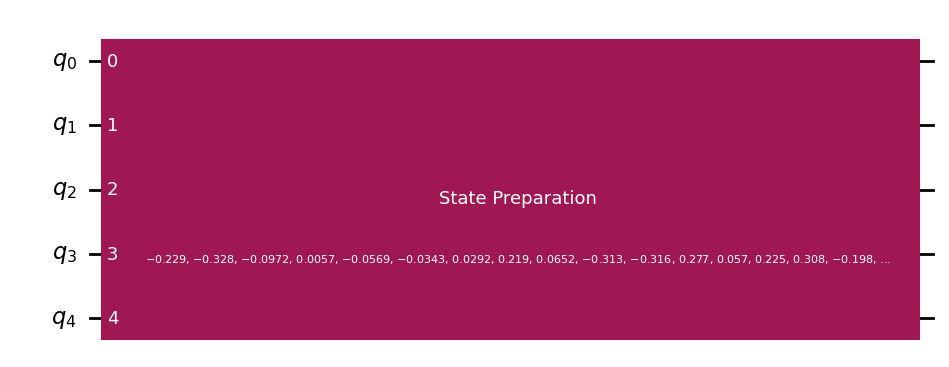

In [22]:
qc = QuantumCircuit(len(qbits))
qc.append(StatePreparation(vector), qbits)
display(qc.draw(output="mpl"))

In [31]:
X_iso

array([[-1.53629818e+01, -3.37232433e+01, -4.83259836e+01, ...,
        -5.64459116e+00, -3.04108789e+01, -2.17341996e+01],
       [-9.10263677e+01, -7.98334264e+01,  1.26731686e-01, ...,
        -1.33300070e+00,  7.41104594e+01, -2.01963136e+01],
       [-7.30796256e+01, -4.82663794e+00, -2.05729668e+01, ...,
        -7.39577115e-01, -2.74852927e+00, -1.46819707e-01],
       ...,
       [ 4.96191575e+02, -1.95547733e+02, -9.25988170e+01, ...,
        -5.62076881e+00,  3.19648723e+00, -3.42108526e+01],
       [ 2.94468220e+02,  1.90603966e+02, -1.39499011e+02, ...,
        -5.12632707e+01, -1.76959532e+01, -5.86563215e+00],
       [-6.83402496e+01, -4.63795014e+00, -1.88254468e+01, ...,
        -2.83643211e+00, -4.78856922e+00,  7.10067595e-01]])

In [32]:
# normalizing the training dataset for RawFeatureVector
from numpy.linalg import norm

def normalize(X):
    return np.array([x / norm(x) if norm(x) > 0 else x for x in X])

X_train_norm = normalize(X_iso)

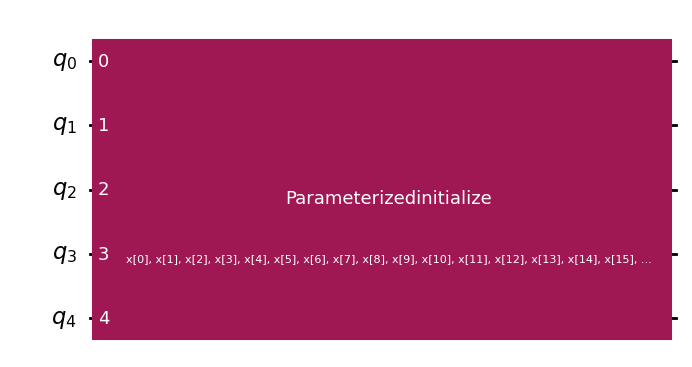

In [36]:
num_features = 32
feature_map = RawFeatureVector(num_features)
display(feature_map.draw(output="mpl"))

In [38]:
# callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()


In [39]:
# parity maps bitstrings to 0 or 1
def parity(x):
    return "{:b}".format(x).count("1") % 2

output_shape = 2

In [40]:
qc = QNNCircuit(num_qubits=4)

In [41]:
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()


In [45]:
# construct ansatz, and optimizer
from qiskit.circuit.library import TwoLocal
ansatz = TwoLocal(num_qubits=5, rotation_blocks="ry", entanglement_blocks="cz", reps=1)

In [46]:
# construct variational quantum classifier
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    loss="cross_entropy",
    optimizer=COBYLA(maxiter=30),
    callback=callback_graph,
    sampler=sampler,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


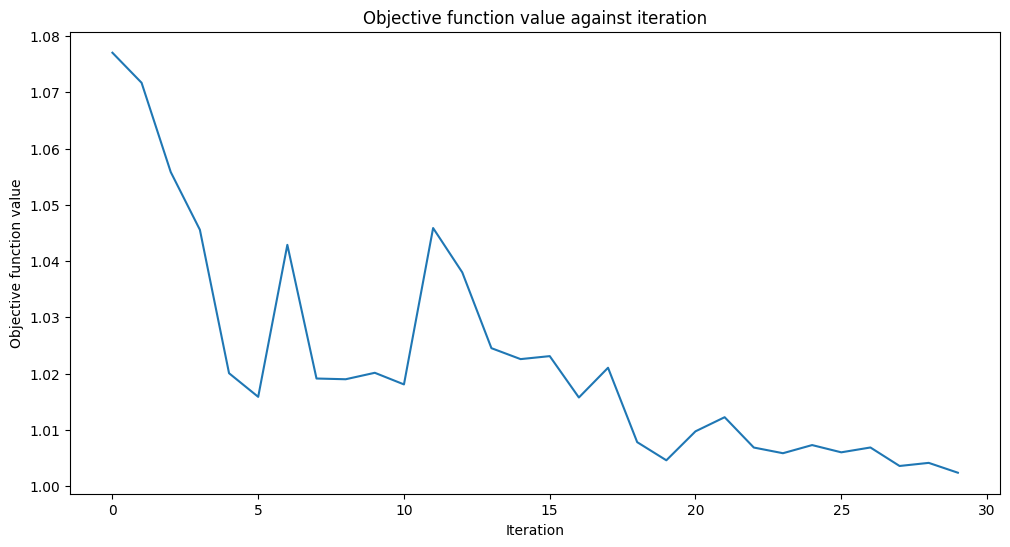

QiskitMachineLearningError: 'Input data has incorrect shape, last dimension is not equal to the number of inputs: 32, but got: 56552.'

In [ ]:
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to data
vqc.fit(X_train_norm, y_one_hot)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)


In [49]:
# score classifier
vqc.score(X_train_norm, y_one_hot)
# evaluate data points
y_predict = vqc.predict(X_train_norm)

In [54]:
from sklearn.metrics import accuracy_score

# Predict labels for the training set
y_pred = np.argmax(y_predict, axis=1)

# Convert one-hot encoded `y_one_hot` back to class labels
y_true = np.argmax(y_one_hot, axis=1)

# Compute accuracy
acc = accuracy_score(y_true, y_pred)
print("Training Accuracy:", acc)


Training Accuracy: 0.5425


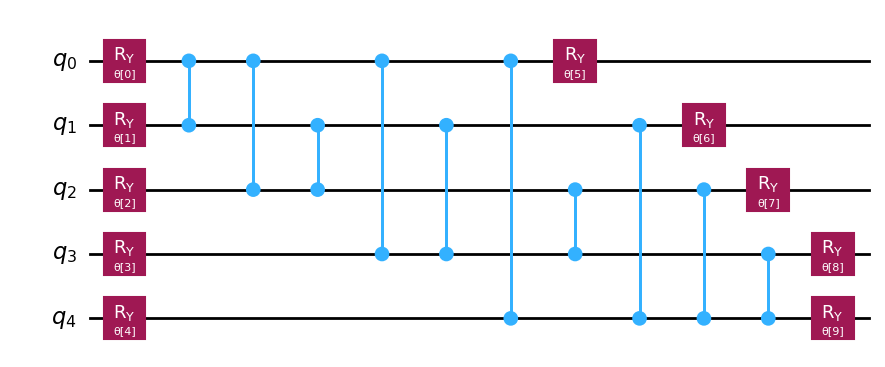

In [55]:
vqc.ansatz.decompose().draw("mpl")